# PA2: Convolutional Neural Networks — SVHN
**CSE 5526: Intro to Neural Networks — Spring 2026**

> **Instructions:** Only edit sections marked with `# TODO`. Do not modify any other code.  
> Run all cells before submitting. Unexecuted notebooks receive a zero.  
> Submit this single file as **`pa2.ipynb`** to your `pa2` folder on GitHub.


## 1. Imports and Setup

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import time

# TODO: Set random seeds for reproducibility using seed 5526
torch.manual_seed(5526)
np.random.seed(5526)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
print(f'PyTorch version: {torch.__version__}')


Using device: cpu
PyTorch version: 2.9.1


## 2. Data Loading

Load the SVHN dataset. SVHN is already divided into `train` and `test` splits by torchvision — no manual splitting is needed.

> **Note:** SVHN images are 32×32 RGB. Labels are 0–9, where label `0` = digit `1`, ..., label `9` = digit `0`.

**Requirements:**
- Use `torchvision.datasets.SVHN` with `split='train'` and `split='test'`
- Apply `transforms.ToTensor()` only — no normalization
- Use a mini-batch size of **50**


In [2]:
BATCH_SIZE = 50
CLASS_NAMES = ['1','2','3','4','5','6','7','8','9','0']

# TODO: Load SVHN train and test sets using torchvision.datasets.SVHN
# Apply transforms.ToTensor() only — no normalization
# Use split='train' for training data and split='test' for final evaluation
train_set = torchvision.datasets.SVHN(root='./data', split='train', download=True, transform=transforms.ToTensor())
test_set = torchvision.datasets.SVHN(root='./data', split='test', download=True, transform=transforms.ToTensor())


# TODO: Split the training set into 80% train and 20% validation
# Use random_split with a Generator seeded at 5526
train_set, val_set = torch.utils.data.random_split(train_set, [int(0.8 * len(train_set)), len(train_set) - int(0.8 * len(train_set))], generator=torch.Generator().manual_seed(5526))

# TODO: Create train_loader, val_loader, and test_loader using DataLoader
# Use BATCH_SIZE=50
# shuffle=True for train_loader, shuffle=False for val_loader and test_loader
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

print(f'Training samples:   {len(train_set)}')
print(f'Validation samples: {len(val_set)}')
print(f'Test samples:       {len(test_set)}')


Training samples:   58605
Validation samples: 14652
Test samples:       26032


## 3. Dataset Visualization

Display sample images to verify the dataset loaded correctly.

**Requirements:**
- Show at least **3 examples per digit class** (10 classes total)
- Label each row with the digit class


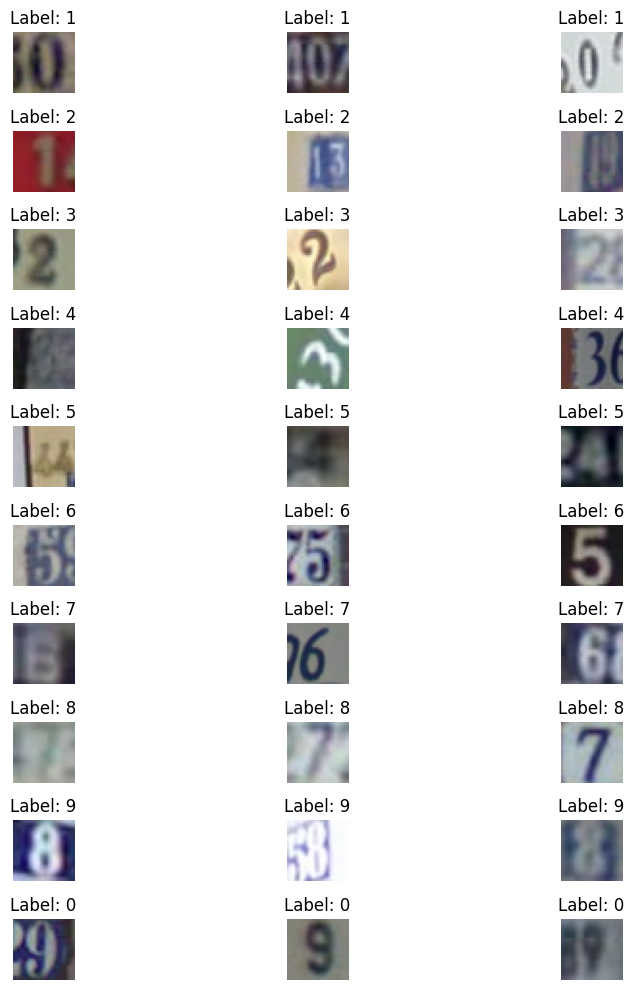

In [3]:
# TODO: Visualize at least 3 sample images per digit class
# Display in a grid with digit labels on the left side
fig = plt.figure(figsize=(10, 10))
for i in range(10): 
    class_samples = [img for img, label in train_set if label == i]
    for j in range(3):
        ax = fig.add_subplot(10, 3, i * 3 + j + 1)
        ax.imshow(class_samples[j].permute(1, 2, 0))
        ax.set_title(f'Label: {CLASS_NAMES[i]}')
        ax.axis('off')
plt.tight_layout()
plt.show()


## 4. Model Definitions

### Xavier Initialization

Implement a helper function that applies Xavier uniform initialization to all `Conv2d` and `Linear` layers in a model, and sets all biases to zero.


In [4]:
def xavier_init(model):
    """
    Apply Xavier uniform initialization to all Conv2d and Linear layers.
    Set all biases to zero.

    Args:
        model (nn.Module): the model to initialize in-place
    """
    for m in model.modules():
        if isinstance(m, (nn.Conv2d, nn.Linear)):
            nn.init.xavier_uniform_(m.weight)
            if m.bias is not None:
                nn.init.zeros_(m.bias)



### Part I — Baseline CNN

Architecture:
- **Conv1:** 3 → 6 filters, 3×3 kernel, stride=1, padding=1 → ReLU
- **Conv2:** 6 → 10 filters, 3×3 kernel, stride=1, padding=1 → ReLU
- **MaxPool:** MaxPool2d(2, 2) at the end of the conv stack
- **FC:** 10×16×16 = 2560 → 10

Spatial flow: 32 → (conv×2) → MaxPool(2,2) → 16  


In [5]:
class BaselineCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # TODO: Define self.conv_layers (nn.Sequential)
        
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 6, kernel_size=3, stride=1, padding=1),  # (N, 6, 32, 32)
            nn.ReLU(),
            nn.Conv2d(6, 10, kernel_size=3, stride=1, padding=1),  # (N, 10, 32, 32)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),                 # (N, 16, 16, 16)
        )

        # TODO: Define self.fc (nn.Linear, input=10*16*16=2560, output=10)
        self.fc = nn.Linear(10 * 16 * 16, 10)

    def forward(self, x):
        """
        Args:
            x (Tensor): input batch of shape (N, 3, 32, 32)
        Returns:
            Tensor: logits of shape (N, 10)
        """
        x = self.conv_layers(x)  # (N, 10, 16, 16)
        x = x.view(x.size(0), -1)  # Flatten to (N, 10*16*16)
        x = self.fc(x)  # (N, 10)
        return x


baseline_model = BaselineCNN()
xavier_init(baseline_model)
print(f'Baseline parameters: {sum(p.numel() for p in baseline_model.parameters() if p.requires_grad):,}')
print(baseline_model)


Baseline parameters: 26,328
BaselineCNN(
  (conv_layers): Sequential(
    (0): Conv2d(3, 6, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(6, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Linear(in_features=2560, out_features=10, bias=True)
)


### Part II-A — Pooling CNN

Same as baseline but with **MaxPool2d(3, stride=3) after each conv layer**.

Spatial flow: 32 → Conv→ReLU→MaxPool(3,s=3) → 10 → Conv→ReLU→MaxPool(3,s=3) → 3  
FC input: 10×3×3 = 90


In [6]:
class PoolingCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # TODO: Define self.conv_layers with MaxPool2d(3, stride=3) after each conv+ReLU
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 6, kernel_size=3, stride=1, padding=1),  # (N, 6, 32, 32)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=3),                 # (N, 3, 10, 10)
            nn.Conv2d(6, 10, kernel_size=3, stride=1, padding=1),  # (N, 10, 10, 10)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=3),                 # (N, 10, 3, 3)  

        )

        # TODO: Define self.fc (input=10*3*3=90, output=10)
        self.fc = nn.Linear(10 * 3 * 3, 10)

    def forward(self, x):
        """
        Args:
            x (Tensor): input batch of shape (N, 3, 32, 32)
        Returns:
            Tensor: logits of shape (N, 10)
        """
        x = self.conv_layers(x)  # (N, 10, 3, 3)
        x = x.view(x.size(0), -1)  # Flatten to (N, 10*3*3)
        x = self.fc(x)  # (N, 10)
        return x


pooling_model = PoolingCNN()
xavier_init(pooling_model)
print(f'Pooling parameters: {sum(p.numel() for p in pooling_model.parameters() if p.requires_grad):,}')
print(pooling_model)


Pooling parameters: 1,628
PoolingCNN(
  (conv_layers): Sequential(
    (0): Conv2d(3, 6, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=3, stride=3, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(6, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=3, stride=3, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Linear(in_features=90, out_features=10, bias=True)
)


### Part II-B — Dropout CNN

Same as baseline but with **Dropout2d(p=0.25) after each conv+ReLU**, before the final MaxPool.

FC input: 10×16×16 = 2560 (spatial unchanged)


In [7]:
class DropoutCNN(nn.Module):
    def __init__(self, dropout_rate=0.25):
        super().__init__()
        # TODO: Define self.conv_layers with Dropout2d(p=dropout_rate) after each conv+ReLU
        self.conv_layers =nn.Sequential(
            nn.Conv2d(3, 6, kernel_size=3, stride=1, padding=1),  # (N, 6, 32, 32)
            nn.ReLU(),
            nn.Dropout2d(p=dropout_rate),
            nn.Conv2d(6, 10, kernel_size=3, stride=1, padding=1),  # (N, 10, 32, 32)
            nn.ReLU(),
            nn.Dropout2d(p=dropout_rate),
            nn.MaxPool2d(kernel_size=2, stride=2),                 # (N, 16, 16, 16)
        )

        # TODO: Define self.fc (input=10*16*16=2560, output=10)
        self.fc = nn.Linear(10 * 16 * 16, 10)

    def forward(self, x):
        """
        Args:
            x (Tensor): input batch of shape (N, 3, 32, 32)
        Returns:
            Tensor: logits of shape (N, 10)
        """
        x = self.conv_layers(x)  # (N, 10, 16, 16)
        x = x.view(x.size(0), -1)  # Flatten to (N, 10*16*16)
        x = self.fc(x)  # (N, 10)
        return x


dropout_model = DropoutCNN(dropout_rate=0.25)
xavier_init(dropout_model)
print(f'Dropout parameters: {sum(p.numel() for p in dropout_model.parameters() if p.requires_grad):,}')
print(dropout_model)


Dropout parameters: 26,328
DropoutCNN(
  (conv_layers): Sequential(
    (0): Conv2d(3, 6, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Dropout2d(p=0.25, inplace=False)
    (3): Conv2d(6, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): Dropout2d(p=0.25, inplace=False)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Linear(in_features=2560, out_features=10, bias=True)
)


## 5. Training and Evaluation Functions

Implement all functions below. Function signatures, docstrings, and the epoch print statement are fixed — do not modify them.

**Training configuration (do not change):**
- Optimizer: SGD, lr=0.05, momentum=0.9, weight_decay=1e-4
- LR scheduler: StepLR, step_size=10, gamma=0.9
- Loss: CrossEntropyLoss
- Early stopping patience: 10 epochs
- Max epochs: 100


In [8]:
def train_model(model, train_loader, val_loader, num_epochs=100,
                lr=0.05, momentum=0.9, patience=10):
    """
    Train model with SGD + StepLR + early stopping on validation loss.
    The test set is never used here — it is reserved for final evaluation only.

    Args:
        model        (nn.Module):   model to train
        train_loader (DataLoader):  training data
        val_loader   (DataLoader):  validation data (for early stopping)
        num_epochs   (int):         maximum number of epochs
        lr           (float):       initial learning rate
        momentum     (float):       SGD momentum
        patience     (int):         early stopping patience on val loss

    Returns:
        train_losses (list[float]): per-epoch training loss
        val_losses   (list[float]): per-epoch validation loss
        train_accs   (list[float]): per-epoch training accuracy
        val_accs     (list[float]): per-epoch validation accuracy
    """
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.9)   
    loss = nn.CrossEntropyLoss()
    for epoch in range(num_epochs):
        #-------------------------
        # Training loop
        #-------------------------
        model.train()
        running_loss = 0.0
        correct, total_train_size = 0, 0
        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss_m = loss(outputs, labels)
            loss_m.backward()
            optimizer.step()
            running_loss += loss_m.item() * inputs.size(0)
            pred = outputs.argmax(dim=1)
            correct += (pred == labels).sum().item()
            total_train_size += labels.size(0)
        train_loss = running_loss / total_train_size
        train_acc = correct / total_train_size
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        #-------------------------
        # Validation loop
        #-------------------------
        model.eval()
        running_loss = 0.0
        correct, total_val_size = 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                outputs = model(inputs)
                loss_m = loss(outputs, labels)
                running_loss += loss_m.item() * inputs.size(0)
                pred = outputs.argmax(dim=1)
                correct += (pred == labels).sum().item()
                total_val_size += labels.size(0)
        val_loss = running_loss / total_val_size
        val_acc = correct / total_val_size
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        # Step the learning rate scheduler
        scheduler.step()
        # Early stopping check
        if epoch > patience and val_losses[-1] > max(val_losses[-patience:]):
            print(f'Early stopping at epoch {epoch}')
            break
    return train_losses, val_losses, train_accs, val_accs





        


In [9]:
def evaluate_model(model, test_loader):
    """
    Evaluate model accuracy on test_loader.

    Args:
        model       (nn.Module):   trained model
        test_loader (DataLoader):  test data

    Returns:
        accuracy  (float):      fraction of correctly classified samples
        preds     (np.ndarray): predicted class indices, shape (N,)
        true_labels (np.ndarray): ground truth class indices, shape (N,)
    """
    model.eval()
    correct, total = 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            pred = outputs.argmax(dim=1)
            correct += (pred == labels).sum().item()
            total += labels.size(0)
            all_preds.append(pred.cpu().numpy())
            all_labels.append(labels.cpu().numpy())
    accuracy = correct / total
    preds = np.concatenate(all_preds)
    true_labels = np.concatenate(all_labels)
    return accuracy, preds, true_labels


In [10]:
def plot_learning_curves(train_losses, val_losses, train_accs, val_accs, title=''):
    """
    Plot loss and accuracy curves for train and validation sets side by side.

    Args:
        train_losses (list[float]): per-epoch training loss
        val_losses   (list[float]): per-epoch validation loss
        train_accs   (list[float]): per-epoch training accuracy
        val_accs     (list[float]): per-epoch validation accuracy
        title        (str):         overall figure title
    """
    epochs = range(1, len(train_losses) + 1)
    plt.figure(figsize=(12, 5))
    plt.suptitle(title)
    # Loss subplot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label='Train Loss')
    plt.plot(epochs, val_losses, label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss Curves')
    plt.legend()
    # Accuracy subplot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accs, label='Train Acc')
    plt.plot(epochs, val_accs, label='Val Acc')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Accuracy Curves')
    plt.legend()
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


In [11]:
def plot_confusion_matrix(y_true, y_pred, class_names, title=''):
    """
    Display a labeled confusion matrix.

    Args:
        y_true      (np.ndarray): ground truth labels, shape (N,)
        y_pred      (np.ndarray): predicted labels, shape (N,)
        class_names (list[str]):  label names for axes
        title       (str):        figure title
    """
    # TODO: Use ConfusionMatrixDisplay, cmap='Blues', rotate x-tick labels 45 degrees
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap='Blues', xticks_rotation=45)
    plt.title(title)
    plt.show()  


## 6. Part I — Baseline

In [12]:
print('Training Baseline CNN...')
print('=' * 70)
train_losses, val_losses, train_accs, val_accs = train_model(
    baseline_model, train_loader, val_loader,
    num_epochs=100, lr=0.05, momentum=0.9, patience=10
)


Training Baseline CNN...


### (1) Learning Curves

> **TODO (written answer):** Does the baseline overfit, underfit, or reasonably fit? Justify using the curves.


The basline seems to underfit. This is due to the lack of change from both the loss and accuracy curves. The curves illustrate the the model is not performing meaningful updates. 

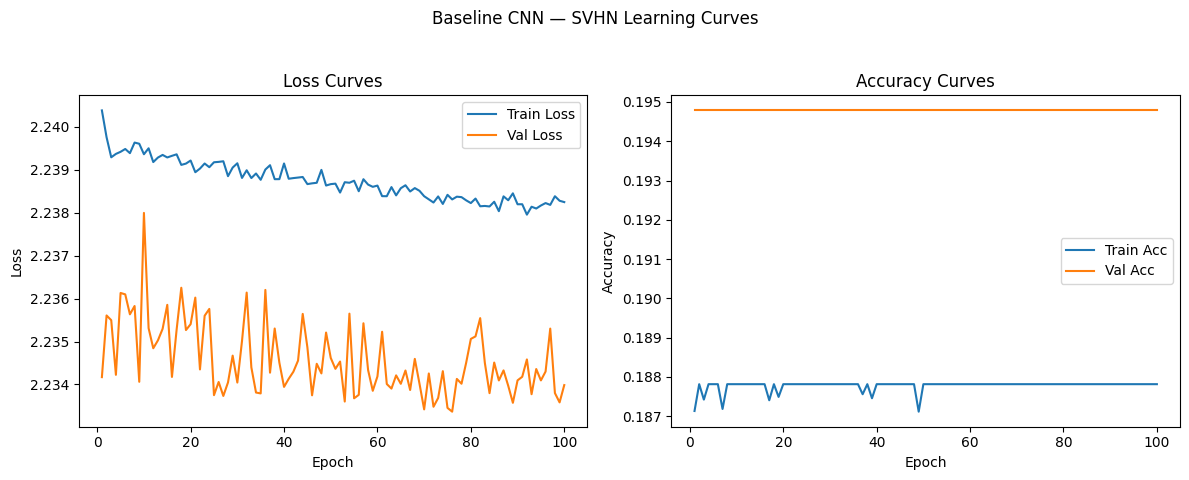

Final Train Acc: 0.1878 | Final Val Acc: 0.1948


In [13]:
plot_learning_curves(train_losses, val_losses, train_accs, val_accs,
                     title='Baseline CNN — SVHN Learning Curves')
print(f'Final Train Acc: {train_accs[-1]:.4f} | Final Val Acc: {val_accs[-1]:.4f}')



### (2) Test Accuracy and Confusion Matrix

Baseline Val Accuracy: 0.1959 (19.59%)


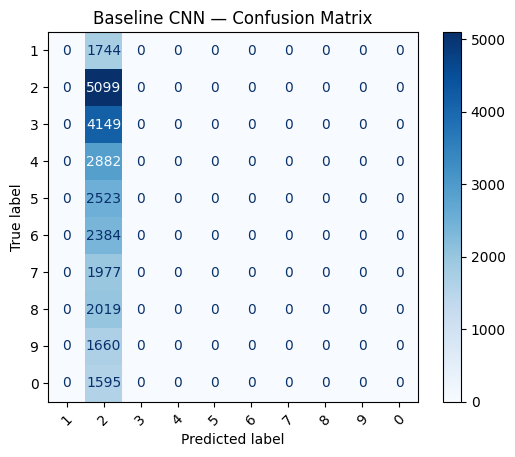

In [14]:
test_acc, preds, true_labels = evaluate_model(baseline_model, test_loader)
print(f'Baseline Val Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)')

plot_confusion_matrix(true_labels, preds, CLASS_NAMES,
                      title='Baseline CNN — Confusion Matrix')


---
## 7. Part II — Experiment 1: Max Pooling


In [15]:
print('Training CNN + MaxPool(3x3, stride=3)...')
print('=' * 70)
p_train_losses, p_val_losses, p_train_accs, p_val_accs = train_model(
    pooling_model, train_loader, val_loader,
    num_epochs=100, lr=0.05, momentum=0.9, patience=10
)


Training CNN + MaxPool(3x3, stride=3)...


### Pooling — Outcomes

> **TODO (written answer):** How does max pooling affect? Do the kernels look different?


The max pooling has not seemed to have an affect. Usually, max pooling with such a large stride would result in a loss of features for the linear function;However, the baseline CNN is underfit and therefore has not changed from the max pooling.

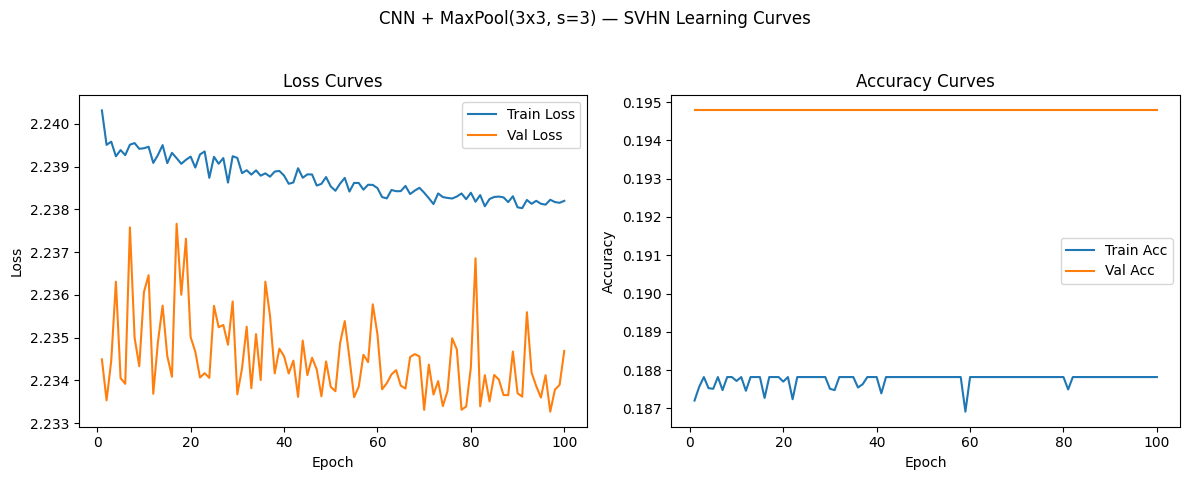

Pooling Val Accuracy: 0.1959 (19.59%)


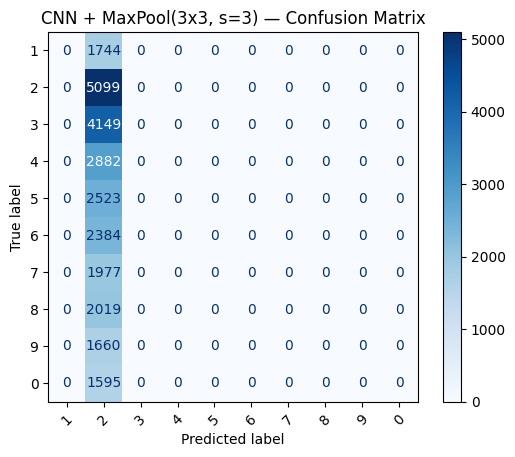

In [16]:
plot_learning_curves(p_train_losses, p_val_losses, p_train_accs, p_val_accs,
                     title='CNN + MaxPool(3x3, s=3) — SVHN Learning Curves')

test_acc_p, preds_p, labels_p = evaluate_model(pooling_model, test_loader)
print(f'Pooling Val Accuracy: {test_acc_p:.4f} ({test_acc_p*100:.2f}%)')

plot_confusion_matrix(labels_p, preds_p, CLASS_NAMES,
                      title='CNN + MaxPool(3x3, s=3) — Confusion Matrix')


---
## 8. Part II — Experiment 2: Dropout


In [17]:
print('Training CNN + Dropout(p=0.25)...')
print('=' * 70)
d_train_losses, d_val_losses, d_train_accs, d_val_accs = train_model(
    dropout_model, train_loader, val_loader,
    num_epochs=100, lr=0.05, momentum=0.9, patience=10
)


Training CNN + Dropout(p=0.25)...


### Dropout — Outcomes

> **TODO (written answer):** How does dropout affect? Compare the train/test loss gap to the baseline.


The dropout does not seem to have an affect, just as the max pooling. 

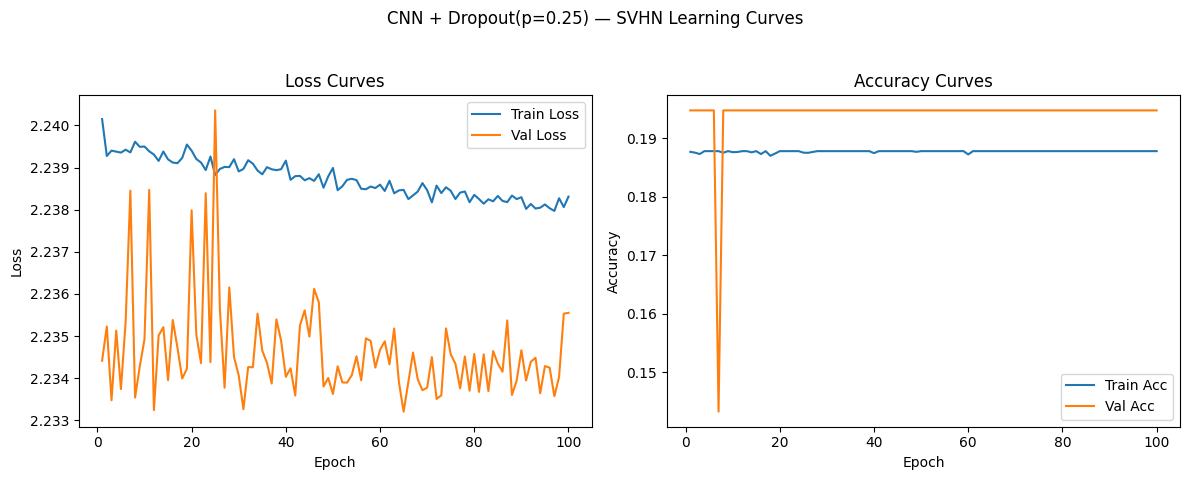

Dropout Val Accuracy: 0.1959 (19.59%)


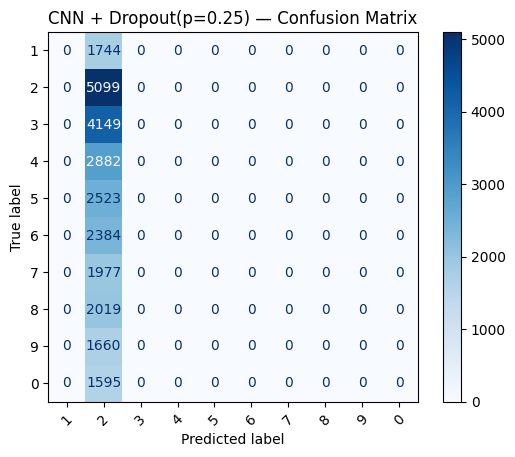

In [18]:
plot_learning_curves(d_train_losses, d_val_losses, d_train_accs, d_val_accs,
                     title='CNN + Dropout(p=0.25) — SVHN Learning Curves')

test_acc_d, preds_d, labels_d = evaluate_model(dropout_model, test_loader)
print(f'Dropout Val Accuracy: {test_acc_d:.4f} ({test_acc_d*100:.2f}%)')

plot_confusion_matrix(labels_d, preds_d, CLASS_NAMES,
                      title='CNN + Dropout(p=0.25) — Confusion Matrix')

---
## 9. Part II — Experiment 3: Momentum Comparison (β=0.9 vs β=0.5)

Train the **same baseline architecture** with momentum β=0.5. All other settings are identical.  
Then compare against the baseline (β=0.9) results from Section 6.


In [19]:
# TODO: Instantiate a new BaselineCNN, apply xavier_init, and train with momentum=0.5
# Store results as: m05_train_losses, m05_val_losses, m05_train_accs, m05_val_accs
m05_model = BaselineCNN()
xavier_init(m05_model)
m05_train_losses, m05_val_losses, m05_train_accs, m05_val_accs = train_model(
    m05_model, train_loader, val_loader,
    num_epochs=100, lr=0.05, momentum=0.5, patience=10
)


### Momentum — Outcomes

> **TODO (written answer):** What does this tell you about the role of momentum in SGD?


Momentum seems to play a huge role in SGD, as we can see by the dramatic change in the graphs below. We went from an underfit baseline CNN, to a model that has much better loss and accuracy curves. 

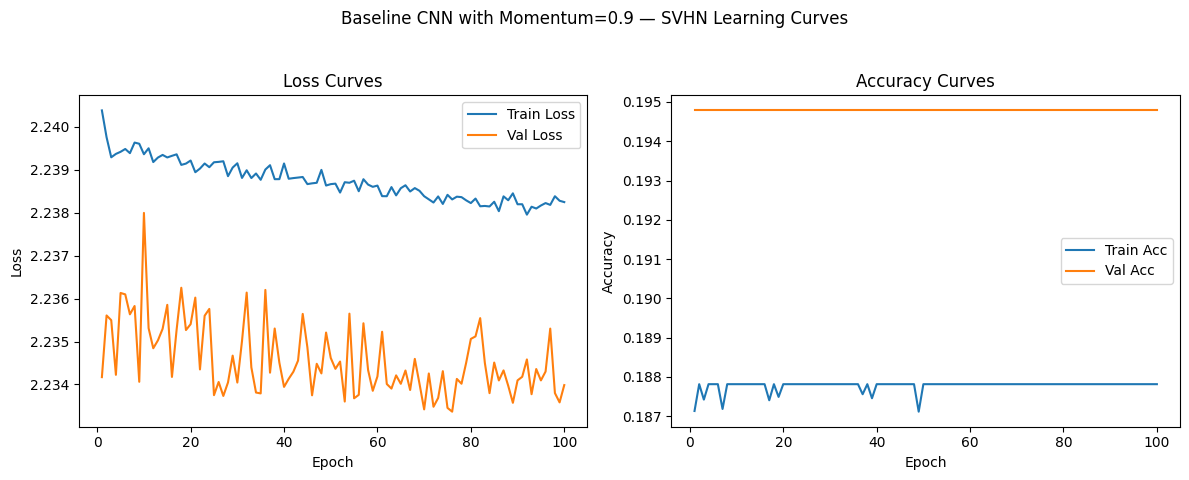

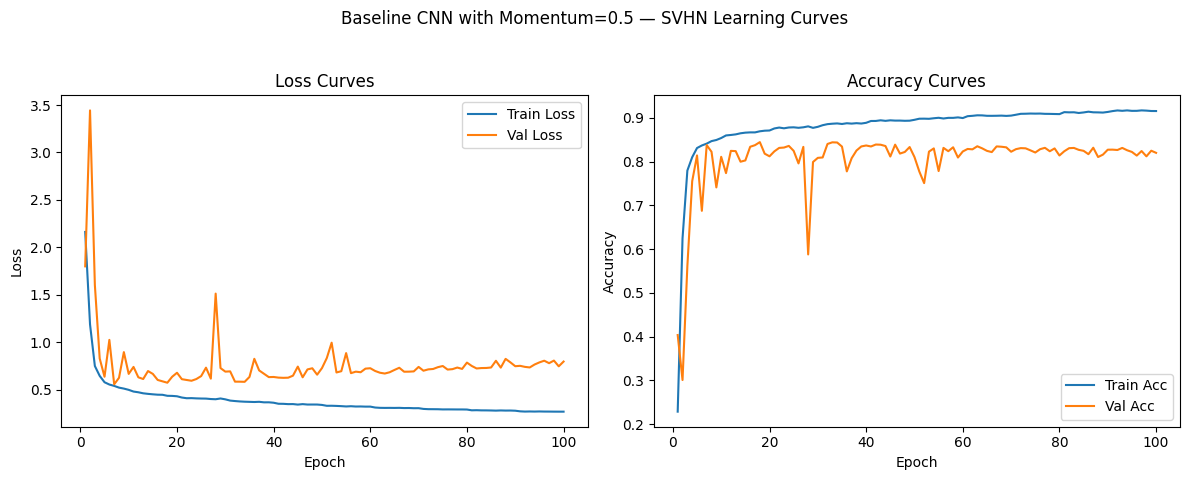

Momentum β=0.9 Val Accuracy: 19.59%
Momentum β=0.5 Val Accuracy: 79.32%


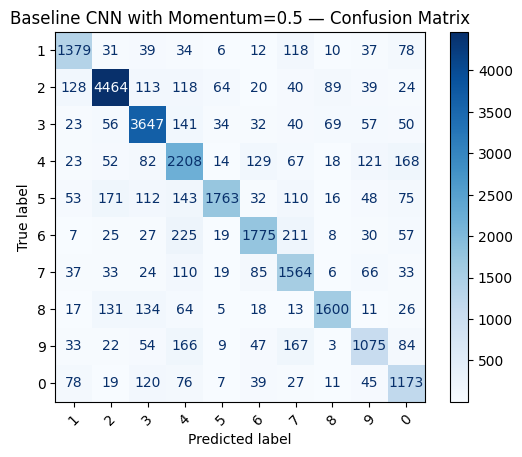

In [20]:
# TODO: Plot both runs (β=0.9 and β=0.5) on the same axes
# Two subplots: loss and accuracy. Distinguish runs by color or linestyle.
plot_learning_curves(train_losses, val_losses, train_accs, val_accs,
                     title='Baseline CNN with Momentum=0.9 — SVHN Learning Curves')
plot_learning_curves(m05_train_losses, m05_val_losses, m05_train_accs, m05_val_accs,
                     title='Baseline CNN with Momentum=0.5 — SVHN Learning Curves')


# TODO: Evaluate β=0.5 model and print test accuracy
m05_test_acc, preds, true_labels = evaluate_model(m05_model, test_loader)

print(f'Momentum β=0.9 Val Accuracy: {test_acc*100:.2f}%')
print(f'Momentum β=0.5 Val Accuracy: {m05_test_acc*100:.2f}%')

# TODO: Plot confusion matrix
plot_confusion_matrix(true_labels, preds, CLASS_NAMES,
                      title='Baseline CNN with Momentum=0.5 — Confusion Matrix')

---
## 10. Summary Table

In [21]:
# TODO: Print a summary table of test accuracy across all four experiments
# Baseline (β=0.9) | MaxPooling | Dropout | Baseline (β=0.5)
print('Summary of Test Accuracies:')
print(f'Baseline (β=0.9): {test_acc*100:.2f}%')
print(f'Baseline (β=0.5): {m05_test_acc*100:.2f}%')

Summary of Test Accuracies:
Baseline (β=0.9): 19.59%
Baseline (β=0.5): 79.32%
